In [96]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from tqdm import trange

# import  settings
import plot_settings
plot_settings.apply()

In [62]:
path = "data/df_c_dot.csv"
df = pd.read_csv(path, sep=r",", engine="python")
df = df.iloc[:, 1:]  # Remove   first column

path = "data/df_c_dot_test.csv"
df_test = pd.read_csv(path, sep=r",", engine="python")
df_test = df_test.iloc[:, 1:]  # Remove   first column

display(df_test)

,I,co,cn,c-dot,dt
0,0.35,29267.402799,29269.170460,0.927736,2.000616
1,0.35,29269.170460,29271.028540,0.975192,2.000616
2,0.35,29271.028540,29272.957836,1.012568,2.000616
3,0.35,29272.957836,29274.951090,1.046136,2.000616
4,0.35,29274.951090,29276.998282,1.074445,2.000616
...,...,...,...,...,...
5857,1.40,45504.239669,45523.757912,10.233068,2.002738
5858,1.40,45523.757912,45543.276153,10.233067,2.002738
5859,1.40,45543.276153,45562.794392,10.233066,2.002738
5860,1.40,45562.794392,45582.312629,10.233065,2.002738


(14991, 2)
(14991, 1)
[[ 0.03663796 -0.81655752]
 [ 0.53475231 -1.32768048]
 [-0.95959072 -0.34337112]
 ...
 [-0.46147638 -1.17721104]
 [-0.95959072 -1.0985902 ]
 [-0.46147638  1.46785592]]
[[5.4817646 ]
 [7.28789187]
 [1.82733344]
 ...
 [3.65390028]
 [1.8273317 ]
 [3.65466687]]


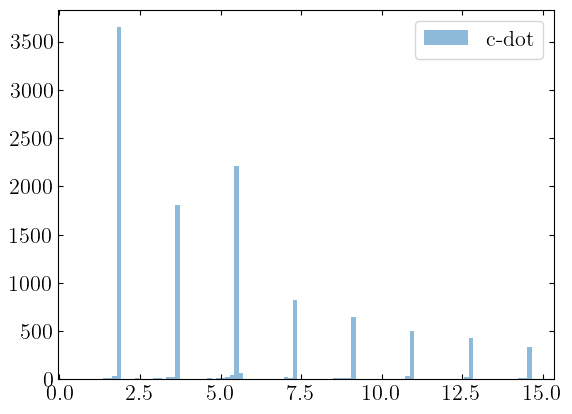

In [150]:
# X = df[['I', 'co', 'dt']].to_numpy()
# y = df[['c-dot']].to_numpy()
X = df[['I', 'co']].to_numpy()
y = df[['c-dot']].to_numpy()
print(X.shape)
print(y.shape)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Scale to [0, 1] range
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_X = StandardScaler()
scaler_X.fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
X_valid_scaled = scaler_X.transform(X_valid)


scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled = scaler_y.transform(y_test)
y_valid_scaled = scaler_y.transform(y_valid)

print(X_train_scaled)
print(y_train)

plt.hist(y_train[:, 0], bins=100, alpha=0.5, label='c-dot')
plt.legend()

In [ ]:
model = keras.models.Sequential([   
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(1024*3, activation='relu'),
    keras.layers.Dense(512*3, activation='relu'),       # No gain
    keras.layers.Dense(256*3, activation='relu'),       # No gain
    keras.layers.Dense(y_train.shape[1], activation='relu'),
])

model.compile(
  optimizer='adam', loss='mse', metrics=['accuracy'])

In [ ]:
model = keras.models.Sequential([   
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(1024*3, activation='relu'),
    keras.layers.Dense(y_train.shape[1], activation='relu'),
])

model.compile(
  optimizer='adam', loss='mse', metrics=['accuracy'])

In [169]:
epochs = 100     ## Number of epoch to run
batch_size = 80  ## Number of samples per gradient update

es = keras.callbacks.EarlyStopping('val_loss', patience=50, restore_best_weights = True)

# Train the model
history = model.fit(
  X_train_scaled, y_train,
  epochs=epochs,
  verbose = 1,
  batch_size=batch_size,
  callbacks=[es],
  validation_data=(X_valid_scaled, y_valid)
  )

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0000e+00 - loss: 1.7072 - val_accuracy: 0.0000e+00 - val_loss: 0.1923
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0000e+00 - loss: 0.2068 - val_accuracy: 0.0000e+00 - val_loss: 0.1011
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0000e+00 - loss: 0.1206 - val_accuracy: 0.0000e+00 - val_loss: 0.2616
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0000e+00 - loss: 0.1113 - val_accuracy: 0.0000e+00 - val_loss: 0.2488
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0000e+00 - loss: 0.0857 - val_accuracy: 0.0000e+00 - val_loss: 0.0342
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.0000e+00 - loss: 0.0493 - val_accuracy: 0.0000e+00 - val_loss: 0.0450
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.0000e+00 - loss: 0.0460 - val_accuracy: 0.0000e+00 - val_loss: 0.0719
Epoch 8/100
141/141 ━━━━━━━━━━━━━━

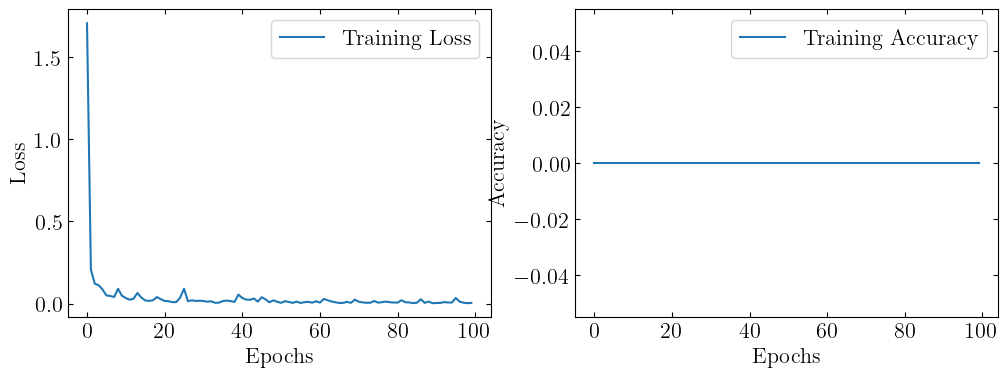

In [170]:
train_loss = history.history['loss']
accuracy = history.history['accuracy']
#valid_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_loss, label='Training Loss')
ax2.plot(accuracy, label='Training Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax1.legend()
ax2.legend()

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Text(0, 0.5, 'Predicted c_dot')

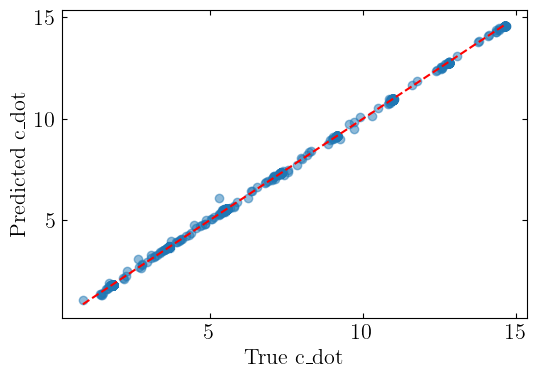

In [171]:
pred_scaled = model.predict(X_test_scaled)

# pred_denorm = scaler_y.inverse_transform(pred_scaled)
pred_denorm = pred_scaled

c_dot_pred = pred_denorm[:, 0]
c_dot_true = y_test[:, 0]

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 4))
ax1.scatter(c_dot_true, c_dot_pred, alpha=0.5)
ax1.plot([c_dot_true.min(), c_dot_true.max()], [c_dot_true.min(), c_dot_true.max()], 'r--', label='y=x')
ax1.set_xlabel('True c_dot')
ax1.set_ylabel('Predicted c_dot')



In [180]:
# Setup for time evolution
i = 0.85
I = df_test.iloc[df_test['I'] == i]['I'].iloc[0]
c = df_test.iloc[0]['co']
print(I)

dt = df_test.iloc[0]['dt']
print(dt)
num_steps = df_test.iloc[df_test['I'] == i]['I'].shape[0]
print(num_steps)
t_max = num_steps * dt
t = np.linspace(0, t_max, num_steps)
print(t)



0.85
2.000615855528147
1441
[0.00000000e+00 2.00200517e+00 4.00401034e+00 ... 2.87888344e+03
 2.88088544e+03 2.88288745e+03]


In [173]:
def derivative(c, step):
    input_features = np.array([[I, c]])
    input_scaled = scaler_X.transform(input_features)
    pred_scaled = model.predict(input_scaled, verbose=0)

    # pred_denorm = scaler_y.inverse_transform(pred_scaled)
    pred_denorm = pred_scaled
    
    c_dot = pred_denorm[0, 0]
    return c_dot

def Euler_step(c, step):
    c_dot = derivative(c, step)
    c_next = c + c_dot * dt
    return c_next

def evolver(c, num_steps):
    c_history = [c]
    
    for step in trange(0, num_steps-1):
        c = Euler_step(c, step)
        c_history.append(c)
    
    return np.array(c_history)

c_history = evolver(c, num_steps)

100%|██████████| 1440/1440 [00:42<00:00, 34.06it/s]


1441


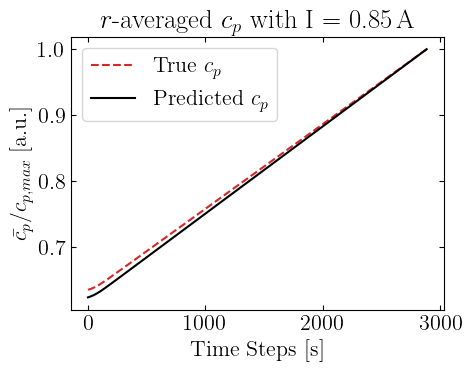

In [202]:
print(len(c_history))

fig, ax1 = plt.subplots(1, 1, figsize=(5, 4))
ax1.plot(t, df_test.iloc[df_test['I'] == i]['cn'] / np.max(df_test.iloc[df_test['I'] == i]['cn']), '--', label=r'True $c_p$', color='tab:red')
ax1.plot(t, c_history/np.max(c_history), '-', label=r'Predicted $c_p$', color='black')
ax1.set_xlabel('Time Steps [s]')
ax1.set_ylabel(r'$\bar{c_p} / c_{p,max}$ [a.u.]')
ax1.set_title(rf'$r$-averaged $c_p$ with I = {I}\,A')
ax1.legend()
plt.tight_layout()
plt.savefig('prg_figs/c_p_evolution.pdf')